(;)<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [178]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [179]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [180]:
## Write your code here
#Column Names - 
print(df.columns)

#Data types
df.dtypes

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)

ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

In [181]:
df.info(verbose=False)

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [182]:
## Write your code here
#missing data
missing_values=df.isnull()
print(missing_values)

missing = df.isnull().sum()
print("Number of missing values:", missing) #True value is missing

#seperate the column types from catergory and numerical
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(exclude=['number']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


print('\nRemaining missing values:',
      df.isna().sum().sum())
print('Final shape:', df.shape)

       ResponseId  MainBranch    Age  Employment  RemoteWork  Check  \
0           False       False  False       False       False  False   
1           False       False  False       False       False  False   
2           False       False  False       False       False  False   
3           False       False  False       False        True  False   
4           False       False  False       False        True  False   
...           ...         ...    ...         ...         ...    ...   
65432       False       False  False       False       False  False   
65433       False       False  False       False       False  False   
65434       False       False  False       False       False  False   
65435       False       False  False       False       False  False   
65436       False       False  False       False        True  False   

       CodingActivities  EdLevel  LearnCode  LearnCodeOnline  ...  \
0                 False    False      False             True  ...   
1        

In [183]:
df.isnull().sum()

ResponseId             0
MainBranch             0
Age                    0
Employment             0
RemoteWork             0
                      ..
JobSatPoints_11        0
SurveyLength           0
SurveyEase             0
ConvertedCompYearly    0
JobSat                 0
Length: 114, dtype: int64

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [184]:
## Write your code here
#value counts for each column
#Employment distribution
print('Employment value counts:\n')
print(df['Employment'].value_counts(dropna=False))

#Job Sat Distribution
print('\nJobSat value Counts:\n')
print(df['JobSat'].value_counts(dropna=False))

#Years of Professional Coding Experience
print('\nYearsCodePro value counts:\n')
print(df['YearsCodePro'].value_counts(dropna=False))

Employment value counts:

Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking f

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


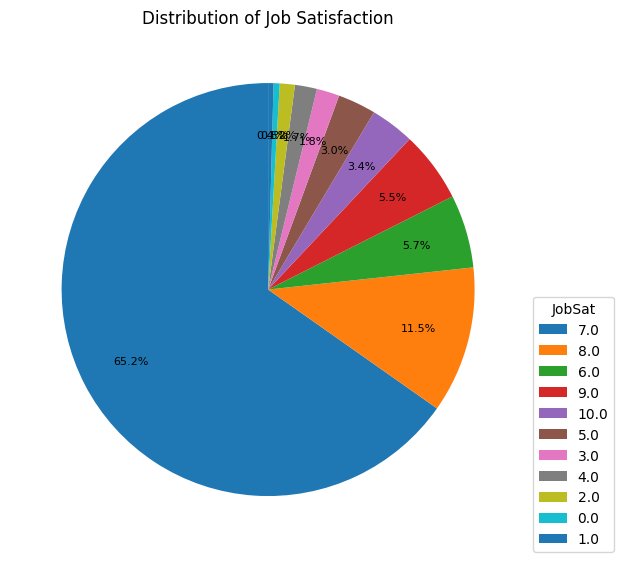

In [185]:
## Write your code here
job_sat_counts = df['JobSat'].value_counts()

#Plot pie
fig, ax = plt.subplots(figsize=(10,6))

wedges, texts, autotexts = ax.pie(
    job_sat_counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
textprops={'fontsize': 8})
plt.title('Distribution of Job Satisfaction')
plt.ylabel('')

ax.legend(
    wedges,
    job_sat_counts.index,
    title='JobSat',
    loc='upper left',
    bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

#each slice is a job satisfaction category, the size is how many people chose that response. and the % labels are the proportion of responses.

                    

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


In [186]:
## Write your code here
#Frequency
for col in ['LanguageHaveWorkedWith', 'LanguageWantToWorkWith']:
    print(f'\n==={col}===')
    print(df[col].value_counts(dropna=False))


===LanguageHaveWorkedWith===
LanguageHaveWorkedWith
HTML/CSS;JavaScript;TypeScript                                                                                                          6694
Python                                                                                                                                   832
HTML/CSS;JavaScript;PHP;SQL                                                                                                              503
C#                                                                                                                                       452
HTML/CSS;JavaScript                                                                                                                      452
                                                                                                                                        ... 
Elixir;HTML/CSS;JavaScript;Lua;PowerShell;Python;Ruby;SQL                                            

In [187]:
!pip install matplotlib-venn

In [188]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

LanguageHaveWorkedWith
JavaScript                 43184
HTML/CSS                   37508
Python                     30719
SQL                        30682
TypeScript                 28842
Bash/Shell (all shells)    20412
Java                       18239
C#                         16318
C++                        13827
C                          12184
PHP                        10951
PowerShell                  8328
Go                          8103
Rust                        7559
Kotlin                      5665
Lua                         3728
Dart                        3594
Assembly                    3233
Ruby                        3147
Swift                       2829
R                           2595
Visual Basic (.Net)         2499
MATLAB                      2378
VBA                         2248
Groovy                      2004
Scala                       1547
Perl                        1482
GDScript                    1402
Objective-C                 1283
Elixir              

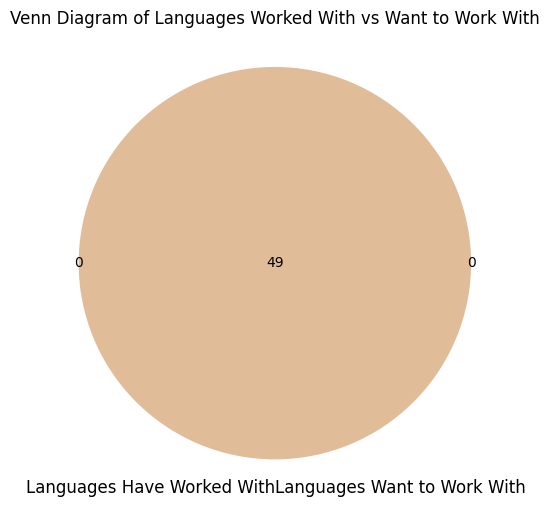

In [189]:
#Above is messy and not ideal to try and analyse, will clean further using split and explode
#LanguageHaveWorkedWith
Lang_workedwith = df['LanguageHaveWorkedWith'].str.split(';')
Lang_workedwith = Lang_workedwith.explode()
Lang_count=Lang_workedwith.value_counts()
print(Lang_count)

#LanguageWantToWorkWith
Lang_want = df['LanguageWantToWorkWith'].str.split(';')
Lang_want=Lang_want.explode()
Lang_want_count = Lang_want.value_counts()
print(Lang_want_count)

#get unique values
Worked_set = set(Lang_workedwith.dropna().unique())
Wanted_set = set(Lang_want.dropna().unique())

#create the Venn Diagram
plt.figure(figsize=(8,6))
venn2([Worked_set, Wanted_set],
      set_labels=('Languages Have Worked With', 'Languages Want to Work With'))

plt.title('Venn Diagram of Languages Worked With vs Want to Work With')
plt.show()
    


### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


In [190]:
df['RemoteWork'].unique()

<ArrowStringArray>
['Remote', 'Hybrid (some remote, some in-person)', 'In-person']
Length: 3, dtype: str

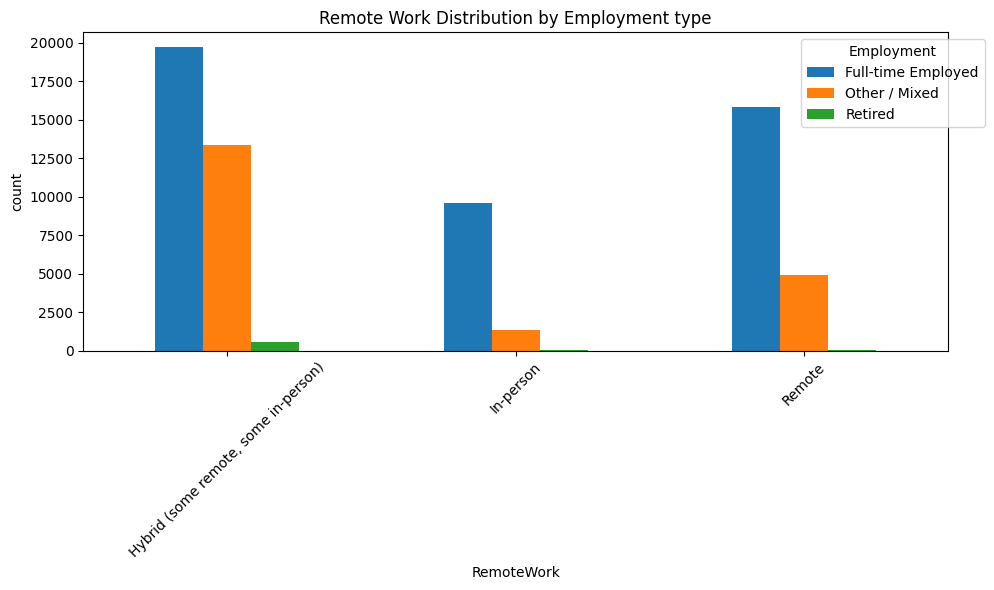

In [191]:
#The dataset does nto include a region or country variable, so it is not possible to visualize RemoteWork by region. 
#Instead RemoteWork is analysed against another relevent variable such as Employment.
#Shorten Employment Labels and tidy - 
df['Employment_clean'] =( df['Employment']
.str.replace('Employed, full-time', 'Full-time Employed', regex=False)
.str.replace('Employed,part-time', 'Part-time Employed', regex=False)
.str.replace('Student,full-time', 'Full-time Student', regex=False)
.str.replace('Student,part-time', 'Part-time Student', regex=False)
.str.replace('Independentcontractor,freelancer,orself-employed', 'Self-employed / Contractor', regex=False)
.str.replace('Notemployed,butlookingforwork', 'Seeking Employment', regex=False)
.str.replace('Notemployed,andnotlookingforwork', 'Not-Seeking Employment', regex=False)
.str.replace('Retired', 'Retired', regex=False))

def simp_employment(emp):
    emp = str(emp)
    
    if 'Full-time Employed' in emp:
        return 'Full-time Employed'
    elif 'Part-time Employed' in emp:
        return 'Part-time Employed'
    elif 'Self-employed / Contractor' in emp:
        return 'Self-employed / contractor'
    elif 'Full-time Student' in emp or 'Part-time Student' in emp:
        return 'Student'
    elif 'Seeking Employment' in emp:
        return 'Seeking Employment'
    elif 'Not-Seeking Employment' in emp:
        return 'Not-Seeking Employment'
    elif 'Retired' in emp:
        return 'Retired'
    else:
        return 'Other / Mixed'

df['Employment_tidy'] = df['Employment_clean'].apply(simp_employment)

Grouped = pd.crosstab(df['RemoteWork'], df['Employment_tidy'])

#grouped Bar
Grouped.plot(kind='bar', figsize=(10,6))
plt.xlabel('RemoteWork')
plt.ylabel('count')
plt.title('Remote Work Distribution by Employment type')
plt.xticks(rotation=45)
plt.legend(title='Employment', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [192]:
## Write your code here
df_subset = df[['YearsCodePro', 'JobSat']].dropna()

#convert YearsCodePro to number -  
def convert_years(x):
    x=str(x)
    if 'Less than' in x:
        return 0.5
    elif 'More than' in x:
        return float(x.split()[2]) +1
    else:
        return pd.to_numeric(x, errors='coerce')
        
df['YearsCodePro_num'] = df['YearsCodePro'].apply(convert_years)

df["JobSat_num"] = pd.to_numeric(df["JobSat"], errors="coerce")

df = df.dropna(subset=["YearsCodePro_num", "JobSat_num"])

Correlation = df[['YearsCodePro_num', 'JobSat_num']].corr()

print(Correlation)

from scipy import stats
#Calculate the Pearson or Spearman correlation coefficient.
pearson_coef, p_value = stats.pearsonr(df['YearsCodePro_num'], df['JobSat_num'])

print('Pearson Correlation Coefficient:', pearson_coef)
print('P_Value', p_value)
#results r=0.104
#p value=2.94 * 10- resulting in weak possitive (had to get help with the working out of the results)
#p = 2.94e-69  (< 0.05)

                  YearsCodePro_num  JobSat_num
YearsCodePro_num          1.000000    0.065835
JobSat_num                0.065835    1.000000
Pearson Correlation Coefficient: 0.06583493323383838
P_Value 9.013493806135428e-64

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


In [193]:
print(df.columns)

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat', 'Employment_clean', 'Employment_tidy',
       'YearsCodePro_num', 'JobSat_num'],
      dtype='str', length=118)

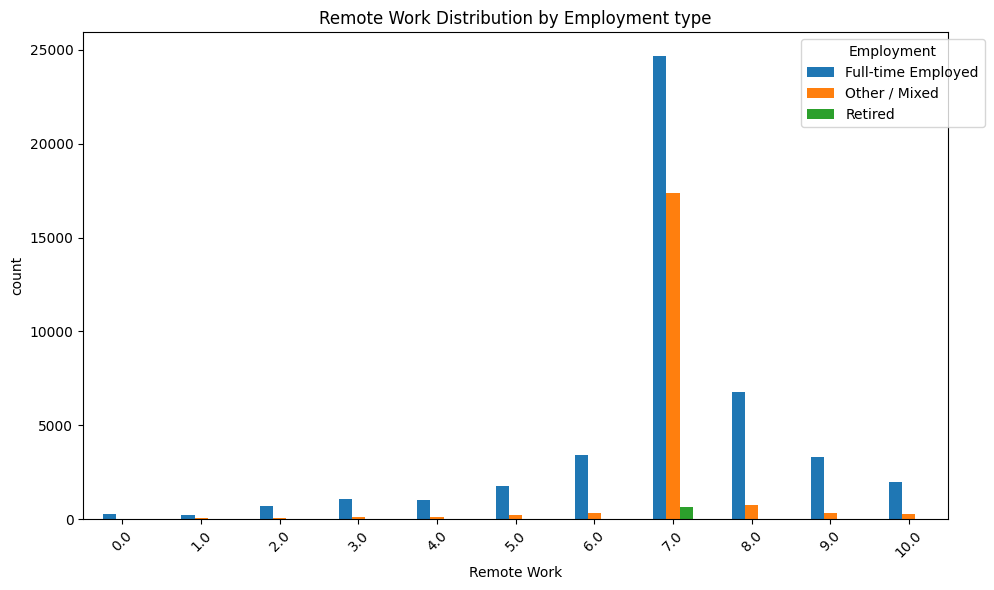

In [194]:
## Write your code here
%matplotlib inline
Grouped = pd.crosstab(df['JobSat'], df['Employment_tidy'])

#grouped Bar
Grouped.plot(kind='bar', figsize=(10,6))
plt.xlabel('Remote Work')
plt.ylabel('count')
plt.title('Remote Work Distribution by Employment type')
plt.xticks(rotation=45)
plt.legend(title='Employment', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [195]:
## Write your code here
df_clean_Dist = df.copy()
df.to_csv('Cleaned_data_dist_csv', index=False)

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.


<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [74]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [75]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [76]:
## Write your code here
#Column Names - 
print(df.columns)

#Data types
df.dtypes

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)

ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

In [77]:
df.info(verbose=False)

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [78]:
from sklearn.impute import SimpleImpute
## Write your code here
#missing data
missing_values=df.isnull()
print(missing_values)

missing = df.isnull().sum()
print("Number of missing values:", missing) #True value is missing

#seperate the column types from catergory and numerical
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(exclude=['number']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df


#impute cat cols


print('\nRemaining missing values:',
      df.isna().sum().sum())
print('Final shape:', df.shape)

ModuleNotFoundError: No module named 'sklearn'

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [ ]:
## Write your code here

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


In [ ]:
## Write your code here

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


In [ ]:
## Write your code here

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


In [ ]:
## Write your code here

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [ ]:
## Write your code here

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


In [ ]:
## Write your code here

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [ ]:
## Write your code here

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
